In [ ]:
!pip install -U transformers datasets peft trl accelerate bitsandbytes

#load the model by tokonzing 

In [3]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2Tokenizer(name_or_path='Qwen/Qwen2.5-0.5B-Instruct', vocab_size=151643, model_max_length=131072, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151647: AddedToken("<|object_ref_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151648: AddedToken("<|box_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151649: AddedToken("<|box_end|>", rstrip=Fa

In [4]:
#try the use the toknizing
text = "Hello, how are you?"

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.encode(text)

print("Tokens:", tokens)
print("Token IDs:", token_ids)

#note Ġ is space before token

Tokens: ['Hello', ',', 'Ġhow', 'Ġare', 'Ġyou', '?']
Token IDs: [9707, 11, 1246, 525, 498, 30]


In [5]:
#load the model
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(model_name)

print(model)
print("Number of parameters:", model.num_parameters())

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [11]:
#prepare minmal dataset
from datasets import Dataset, load_dataset
"""
dataset = Dataset.from_dict({
    "instruction": [
        "What is a 3D printer?",
        "What is a thermistor?",
        "What is LoRA?"
    ],
    "response": [
        "A 3D printer creates physical objects layer by layer.",
        "A thermistor is a resistor whose resistance changes with temperature.",
        "LoRA is a parameter-efficient fine-tuning method."
    ]
})
"""
dataset = load_dataset("databricks/databricks-dolly-15k", split="train")

# Keep only the two columns you need
dataset = dataset.select_columns(["instruction", "response"])
dataset = dataset.select(range(int(len(dataset) * 0.01)))


In [12]:
! pip install -U torchao

In [13]:
#adding lora
from peft import LoraConfig, get_peft_model
config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, config)

model.print_trainable_parameters()

#toknize
def tokenize(example):
    text = f"User: {example['instruction']}\nAssistant: {example['response']}"

    tokens = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=128
    )

    tokens["labels"] = tokens["input_ids"].copy()

    return tokens

tokenized_dataset = dataset.map(tokenize)


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:148: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:331: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [14]:
#train
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

args = TrainingArguments(
    output_dir="./lora_output",
    num_train_epochs=5,
    per_device_train_batch_size=1,
    learning_rate=2e-4,
    logging_steps=1,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

trainer.train()

Step,Training Loss
1,2.110122
2,2.820888
3,2.596489
4,2.811619
5,2.910267
6,2.661151
7,3.080408
8,2.973564
9,1.865623
10,2.990905


TrainOutput(global_step=375, training_loss=2.206043456077576, metrics={'train_runtime': 160.5418, 'train_samples_per_second': 4.672, 'train_steps_per_second': 2.336, 'total_flos': 206460739584000.0, 'train_loss': 2.206043456077576, 'epoch': 5.0})

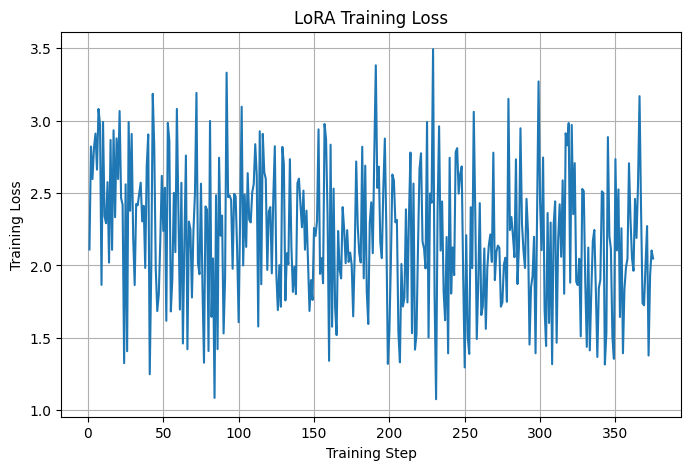

In [15]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.figure(figsize=(8, 5))
plt.plot(steps, losses)
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("LoRA Training Loss")
plt.grid(True)
plt.show()

In [ ]:
#save the adapter , note whole model= freezed model pram + adapter pram (trained)
model.save_pretrained("./lora_adapter")
tokenizer.save_pretrained("./lora_adapter")

In [ ]:
#run the model
from peft import PeftModel
from transformers import AutoModelForCausalLM

base_model = AutoModelForCausalLM.from_pretrained(model_name)

model = PeftModel.from_pretrained(
    base_model,
    "./lora_adapter"
)
prompt = "User: What is a thermistor?\nAssistant:"

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))